In [19]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np




In [2]:
# Load the dataset
transform = transforms.Compose([transforms.ToTensor()])
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [3]:
type(train_set), train_set.data.shape, train_set.targets.shape

(torchvision.datasets.mnist.MNIST,
 torch.Size([60000, 28, 28]),
 torch.Size([60000]))

In [ ]:
train_set.targets[:10], 

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

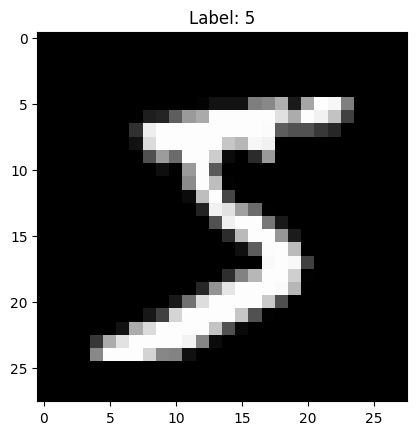

In [6]:
# show the first image 
plt.imshow(train_set.data[0], cmap='gray')
plt.title(f'Label: {train_set.targets[0]}') 
plt.show()

In [5]:
train_set.data[0], train_set.targets[0]

(tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
           18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
         [  0,   0,   0,   0,   0,

In [7]:
from torch.utils.data import DataLoader, random_split

In [10]:
train_set.targets.shape, train_set.targets[:20]

(torch.Size([60000]),
 tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9]))

In [12]:
train_set.targets.unique(), train_set.targets.bincount() 

(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [13]:
count = train_set.targets.bincount() 

In [21]:
len(dir(train_set.data)) 

756

In [22]:
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [23]:
test_set.data.shape, test_set.targets.shape

(torch.Size([10000, 28, 28]), torch.Size([10000]))

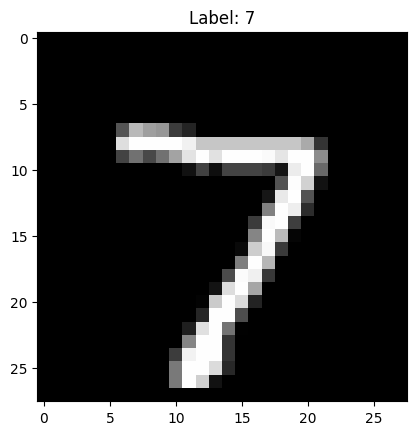

In [24]:
# show me the first image of the test set
plt.imshow(test_set.data[0], cmap='gray')   
plt.title(f'Label: {test_set.targets[0]}')
plt.show()

In [4]:
# MINST Model
class MNISTModel(torch.nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear_relu_stack = torch.nn.Sequential(
            torch.nn.Linear(28*28, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [5]:
model = MNISTModel()


In [6]:
train_set.data[0].shape, train_set.data[0].unsqueeze(0).shape

(torch.Size([28, 28]), torch.Size([1, 28, 28]))

In [8]:
pred = model.forward(train_set.data[0].unsqueeze(0).float())
pred.shape, pred

(torch.Size([1, 10]),
 tensor([[ 6.2583,  1.5679,  2.1020, 11.8739, -8.5502,  4.7375,  6.0862,  0.6914,
          -5.2388, -7.2244]], grad_fn=<AddmmBackward0>))

In [11]:
pred.argmax(dim=1), pred.argmax(dim=1) == train_set.targets[0], train_set.targets[0]

(tensor([3]), tensor([False]), tensor(5))

In [12]:
criterion = torch.nn.CrossEntropyLoss() 
loss = criterion(pred, train_set.targets[0].unsqueeze(0))
loss.item()

7.143931865692139

In [13]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [14]:
optimizer.zero_grad()
loss.backward()
optimizer.step()


In [15]:

pred = model.forward(train_set.data[0].unsqueeze(0).float())
pred

tensor([[ -16.5062,    9.4877,   -0.8728, -263.8658,  -11.7864,  306.6416,
           -0.6612,   22.0597,  -15.4667,   -5.9284]],
       grad_fn=<AddmmBackward0>)

In [16]:
pred.argmax(dim=1)

tensor([5])

In [17]:
pred = model.forward(train_set.data[1].unsqueeze(0).float())
pred.argmax(dim=1), pred.argmax(dim=1) == train_set.targets[1], train_set.targets[1]

(tensor([5]), tensor([False]), tensor(0))

In [ ]:
batch_size = 64
train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
counter = 0
for X, y in train_dataloader:
    # print(f'X shape: {X.shape}, y shape: {y.shape}')
    pred = model.forward(X)
    loss = criterion(pred, y)
    print(f'Batch {counter}, Loss: {loss.item()}')
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    counter += 1
    if counter % 100 == 0:
        print(f'Batch {counter}, Loss: {loss.item()}')
counter

Batch 0, Loss: 2.462709665298462
Batch 1, Loss: 2.3369393348693848
Batch 2, Loss: 2.3840184211730957
Batch 3, Loss: 2.357872724533081
Batch 4, Loss: 2.3815371990203857
Batch 5, Loss: 2.341217041015625
Batch 6, Loss: 2.344414472579956
Batch 7, Loss: 2.3324170112609863
Batch 8, Loss: 2.3586695194244385
Batch 9, Loss: 2.3748037815093994
Batch 10, Loss: 2.329751968383789
Batch 11, Loss: 2.392429828643799
Batch 12, Loss: 2.3380205631256104
Batch 13, Loss: 2.3737688064575195
Batch 14, Loss: 2.3170011043548584
Batch 15, Loss: 2.3658571243286133
Batch 16, Loss: 2.361212968826294
Batch 17, Loss: 2.3440661430358887
Batch 18, Loss: 2.287898302078247
Batch 19, Loss: 2.3796591758728027
Batch 20, Loss: 2.332498550415039
Batch 21, Loss: 2.323859691619873
Batch 22, Loss: 2.366157293319702
Batch 23, Loss: 2.3753561973571777
Batch 24, Loss: 2.320803165435791
Batch 25, Loss: 2.3601982593536377
Batch 26, Loss: 2.2860867977142334
Batch 27, Loss: 2.3342254161834717
Batch 28, Loss: 2.3382811546325684
Batch 2

938

torch.Size([32, 1, 28, 28])

In [22]:
60000 / 64

937.5

In [35]:
para = model.linear_relu_stack.parameters()
next(para).shape

torch.Size([512, 784])

In [31]:
res = model.flatten(train_set.data[0].unsqueeze(0))
res.shape

torch.Size([1, 784])

In [42]:
train_set.data[0].unsqueeze(0).shape

torch.Size([1, 28, 28])

In [45]:
model.forward(train_set.data[0].unsqueeze(0).to(torch.float32)).argmax(dim=1), train_set.targets[0]

(tensor([9]), tensor(5))

In [38]:
train_set.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)